In [ ]:
# ============================================================
# CELL 1: Install and Check GPU
# ============================================================
!pip install ultralytics -q

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print(" No GPU! Go to Runtime → Change runtime type → GPU")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.1 MB/s eta 0:00:00
PyTorch: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4


In [1]:
from google.colab import drive
import os
import shutil
from pathlib import Path
import random

# Mount Google Drive
print("Mounting Google Drive...")
drive.mount('/content/drive')

print("Google Drive mounted!")

# The CWD-30 dataset link you provided
# https://drive.google.com/drive/folders/13X6aRpb47FOns8cPOZtjyOhsSwakKX6T

print("\nIMPORTANT: Add the CWD-30 folder to your Drive first!")
print("Steps:")
print("1. Open: https://drive.google.com/drive/folders/13X6aRpb47FOns8cPOZtjyOhsSwakKX6T")
print("2. Click 'Add shortcut to Drive' (at the top)")
print("3. Choose 'My Drive' and click 'Add'")
print("4. Then run the rest of this cell\n")

input("Press Enter after you've added the shortcut to your Drive...")

# Find the CWD-30 folder in your Drive
print("\nSearching for CWD-30 dataset in your Drive...")

# Common paths where it might be
possible_paths = [
    '/content/drive/MyDrive/CWD30',
    '/content/drive/MyDrive/13X6aRpb47FOns8cPOZtjyOhsSwakKX6T',
    '/content/drive/.shortcut-targets-by-id/13X6aRpb47FOns8cPOZtjyOhsSwakKX6T',
]

cwd30_path = None
for path in possible_paths:
    if os.path.exists(path):
        cwd30_path = path
        print(f"Found CWD-30 at: {path}")
        break

if not cwd30_path:
    print("CWD-30 folder not found. Let's search manually...")
    print("\nYour Drive structure:")
    !ls -la /content/drive/MyDrive/ | head -20

    print("\nPlease enter the path to CWD-30 folder:")
    cwd30_path = input("Path: ")

# Show what's inside
print(f"\nCWD-30 contents:")
!ls -la {cwd30_path}

# Check subdirectories
print("\nSubdirectories:")
for item in os.listdir(cwd30_path):
    item_path = os.path.join(cwd30_path, item)
    if os.path.isdir(item_path):
        num_files = len(os.listdir(item_path))
        print(f"   {item}/ ({num_files} items)")

print("\nDataset located! Ready for processing.")

ModuleNotFoundError: No module named 'google'

In [ ]:
import zipfile
import os
import random

cwd30_zip = '/content/drive/.shortcut-targets-by-id/13X6aRpb47FOns8cPOZtjyOhsSwakKX6T/CWD30/data.zip'

print("Extracting CWD-30 subset (faster approach)...")
print("Extracting only 2000 images for training\n")

extract_path = '/content/cwd30_extracted'
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(cwd30_zip, 'r') as zip_ref:
    # Get all files
    all_files = zip_ref.namelist()

    # Filter only image files
    image_files = [f for f in all_files if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    print(f"Total images in archive: {len(image_files)}")

    # Sample subset
    SUBSET_SIZE = 2000
    if len(image_files) > SUBSET_SIZE:
        random.seed(42)
        selected_images = random.sample(image_files, SUBSET_SIZE)
    else:
        selected_images = image_files

    print(f"Extracting {len(selected_images)} images...")

    # Extract selected images and their labels
    extracted_count = 0
    for i, img_file in enumerate(selected_images):
        if i % 100 == 0:
            print(f"  Progress: {i}/{len(selected_images)}...", end='\r')

        # Extract image
        zip_ref.extract(img_file, extract_path)

        # Try to extract corresponding label
        base_name = os.path.splitext(img_file)[0]
        label_file = base_name + '.txt'

        # Try different label locations
        possible_labels = [
            label_file,
            label_file.replace('images', 'labels'),
            label_file.replace('imgs', 'labels'),
        ]

        for lbl in possible_labels:
            if lbl in all_files:
                zip_ref.extract(lbl, extract_path)
                break

        extracted_count += 1

    print(f"  Progress: {len(selected_images)}/{len(selected_images)}")

print(f"\nExtracted {extracted_count} images!")

# Check structure
print("\nExtracted structure:")
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    if level < 3:
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')
        if files and level < 2:
            print(f'{indent}  ({len(files)} files)')

cwd30_path = extract_path
print(f"\nReady to process from: {cwd30_path}")

📦 Extracting CWD-30 subset (faster approach)...
⚡ Extracting only 2000 images for training

📊 Total images in archive: 196275
⚡ Extracting 2000 images...
  Progress: 2000/2000 ✅

✅ Extracted 2000 images!

📂 Extracted structure:
cwd30_extracted/
  data/
    henbit/
    proso-millet/
    red-bean/
    finger-grass/
    korean-dock/
    perilla/
    purslane/
    fall-panicum/
    white-goosefoot/
    great-millet/
    cockspur-grass/
    asian-flatsedge/
    livid-pigweed/
    nipponicus-sedge/
    smooth-pigweed/
    goosefoot/
    asiatic-dayflower/
    cooper-leaf/
    bean/
    redroot-pigweed/
    sesame/
    early-barnyard-grass/
    bloodscale-sedge/
    peanut/
    corn/
    green-foxtail/
    foxtail-millet/
    poa-annua/
    green-gram/
    indian-goosegrass/

✅ Ready to process from: /content/cwd30_extracted


In [ ]:
import os
import shutil
from pathlib import Path
import random

print("Organizing CWD-30 into YOLO format...")

# Collect all images from extracted data
all_images = []

print("\nScanning extracted files...")
for root, dirs, files in os.walk(cwd30_path):
    for file in files:
        file_path = os.path.join(root, file)
        ext = Path(file).suffix.lower()

        if ext in {'.jpg', '.jpeg', '.png', '.bmp'}:
            all_images.append(file_path)

print(f"Total images in archive: {len(image_files)}")

if len(all_images) == 0:
    print("\nNo images found! Check extraction path:")
    !ls -R {cwd30_path} | head -50
else:
    # Create YOLO directory structure
    print("\nCreating YOLO structure...")
    os.makedirs('/content/dataset/images/train', exist_ok=True)
    os.makedirs('/content/dataset/images/val', exist_ok=True)
    os.makedirs('/content/dataset/labels/train', exist_ok=True)
    os.makedirs('/content/dataset/labels/val', exist_ok=True)

    # Split 80/20
    random.seed(42)
    random.shuffle(all_images)
    split_idx = int(len(all_images) * 0.8)
    train_images = all_images[:split_idx]
    val_images = all_images[split_idx:]

    print(f"Split: {len(train_images)} train, {len(val_images)} val\n")

    # Copy and organize files, generating labels from filenames
    def organize_split(image_list, split_name):
        copied_imgs = 0
        generated_lbls = 0

        # Define class mapping based on data.yaml
        class_map = {'crop': 0, 'weed': 1}

        for i, img_path in enumerate(image_list):
            if i % 50 == 0:
                print(f"  {split_name}: {i}/{len(image_list)}...", end='\r')

            # Copy image
            img_name = os.path.basename(img_path)
            dest_img = f'/content/dataset/images/{split_name}/{img_name}'
            shutil.copy2(img_path, dest_img)
            copied_imgs += 1

            # Generate YOLO label based on filename
            base_name = os.path.splitext(img_name)[0]
            class_label_str = base_name.split('_')[0].lower() # e.g., 'crop' or 'weed'

            if class_label_str in class_map:
                class_id = class_map[class_label_str]
                # Assuming full image is the object (0.5 0.5 1.0 1.0)
                yolo_label_content = f"{class_id} 0.5 0.5 1.0 1.0\n"
                dest_lbl = f'/content/dataset/labels/{split_name}/{base_name}.txt'
                with open(dest_lbl, 'w') as f:
                    f.write(yolo_label_content)
                generated_lbls += 1
            else:
                # This warning can be noisy, only print if truly unexpected
                # print(f"  Warning: Could not determine class for {img_name}. Skipping label generation.")
                pass

        print(f"  {split_name}: {copied_imgs} images, {generated_lbls} generated labels")
        return copied_imgs, generated_lbls

    train_imgs, train_lbls = organize_split(train_images, 'train')
    val_imgs, val_lbls = organize_split(val_images, 'val')

    print(f"\nDataset organized!")
    print(f"   Train: {train_imgs} images, {train_lbls} labels")
    print(f"   Val: {val_imgs} images, {val_lbls} labels")

    # Create data.yaml
    dataset_yaml = """path: /content/dataset
train: images/train
val: images/val

nc: 2
names:
  0: crop
  1: weed
"""

    with open('/content/data.yaml', 'w') as f:
        f.write(dataset_yaml)

    print("\nCreated data.yaml")

    # Verify
    print("\nVerification:")
    !echo -n "Train images: " && ls /content/dataset/images/train | wc -l
    !echo -n "Train labels: " && ls /content/dataset/labels/train | wc -l

    # Show sample label
    print("\nSample label (YOLO format):")
    !head -n 3 /content/dataset/labels/train/*.txt 2>/dev/null | head -5

    # Show sample image
    print("\nSample images:")
    !ls /content/dataset/images/train | head -3

    print("\n" + "="*60)
    print("Dataset ready for training!")
    print("="*60)
    print("\nNext: Run CELL 4 to start training YOLOv8!")

# Ensure dataset_path is always defined, even if no images were found (though unlikely in this flow)
dataset_path = '/content/data.yaml'

🔄 Organizing CWD-30 into YOLO format...

🔍 Scanning extracted files...
📊 Found 2000 images

📁 Creating YOLO structure...
✂️ Split: 1600 train, 400 val

  train: 1600 images, 1600 generated labels ✅
  val: 400 images, 400 generated labels ✅

✅ Dataset organized!
   Train: 1600 images, 1600 labels
   Val: 400 images, 400 labels

✅ Created data.yaml

🔍 Verification:
Train images: 1600
Train labels: 1600

📄 Sample label (YOLO format):
==> /content/dataset/labels/train/crop_bean_w1_0_000021.txt <==
0 0.5 0.5 1.0 1.0

==> /content/dataset/labels/train/crop_bean_w1_0_000450.txt <==
0 0.5 0.5 1.0 1.0

🖼️ Sample images:
crop_bean_w1_0_000021.JPG
crop_bean_w1_0_000450.JPG
crop_bean_w1_0_000525.JPG

🎉 Dataset ready for training!

➡️ Next: Run CELL 4 to start training YOLOv8!


In [ ]:
import zipfile

cwd30_zip = '/content/drive/.shortcut-targets-by-id/13X6aRpb47FOns8cPOZtjyOhsSwakKX6T/CWD30/data.zip'

print("Examining data.zip structure...\n")

with zipfile.ZipFile(cwd30_zip, 'r') as zip_ref:
    # Get all files
    all_files = zip_ref.namelist()[:100]  # Show first 100 files

    print(f"Total files in zip: {len(zip_ref.namelist())}")
    print("\nSample file structure:")

    for file in all_files:
        print(f"  {file}")

    # Count file types
    images = [f for f in zip_ref.namelist() if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    txt_files = [f for f in zip_ref.namelist() if f.endswith('.txt')]
    xml_files = [f for f in zip_ref.namelist() if f.endswith('.xml')]
    json_files = [f for f in zip_ref.namelist() if f.endswith('.json')]

    print(f"\nFile counts:")
    print(f"   Images: {len(images)}")
    print(f"   .txt files: {len(txt_files)}")
    print(f"   .xml files: {len(xml_files)}")
    print(f"   .json files: {len(json_files)}")

    # Show sample of each type
    if txt_files:
        print(f"\nSample .txt files:")
        for f in txt_files[:5]:
            print(f"   {f}")

    if xml_files:
        print(f"\nSample .xml files:")
        for f in xml_files[:5]:
            print(f"   {f}")

    # Check if labels are in YOLO format
    if txt_files:
        print(f"\nChecking label format...")
        sample_label = txt_files[0]
        content = zip_ref.read(sample_label).decode('utf-8')
        print(f"\nSample label content ({sample_label}):")
        print(content[:500])  # Show first 500 chars

🔍 Examining data.zip structure...

📊 Total files in zip: 196306

📁 Sample file structure:
  data/
  data/asian-flatsedge/
  data/asian-flatsedge/weed_asian-flatsedge_w0_0_0162661.jpg
  data/asian-flatsedge/weed_asian-flatsedge_w0_0_0162662.jpg
  data/asian-flatsedge/weed_asian-flatsedge_w0_0_0162663.jpg
  data/asian-flatsedge/weed_asian-flatsedge_w0_0_0162664.jpg
  data/asian-flatsedge/weed_asian-flatsedge_w0_0_0162665.jpg
  data/asian-flatsedge/weed_asian-flatsedge_w0_0_0162666.jpg
  data/asian-flatsedge/weed_asian-flatsedge_w0_0_0162667.jpg
  data/asian-flatsedge/weed_asian-flatsedge_w0_0_0162668.jpg
  data/asian-flatsedge/weed_asian-flatsedge_w0_0_0162669.jpg
  data/asian-flatsedge/weed_asian-flatsedge_w0_0_0162670.jpg
  data/asian-flatsedge/weed_asian-flatsedge_w0_0_0162671.jpg
  data/asian-flatsedge/weed_asian-flatsedge_w0_0_0162672.jpg
  data/asian-flatsedge/weed_asian-flatsedge_w0_0_0162673.jpg
  data/asian-flatsedge/weed_asian-flatsedge_w0_0_0162674.jpg
  data/asian-flatsedge/w

In [ ]:
# ============================================================
# CELL 4: Train YOLOv8
# ============================================================
from ultralytics import YOLO

# Load pretrained model (choose one):
# yolov8n.pt = fastest, smallest
# yolov8s.pt = balanced (RECOMMENDED)
# yolov8m.pt = more accurate, slower

model = YOLO('yolov8s.pt')

# Train
results = model.train(
    data=dataset_path,
    epochs=100,          # Reduce to 50 for faster testing
    imgsz=640,
    batch=16,            # Reduce to 8 if out of memory
    device=0,            # Use GPU
    project='crop_model',
    name='training_run',
    patience=20,
    save=True,

    # Augmentation
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0,
)

print(" Training complete!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.

In [ ]:
# ============================================================
# CELL 5: Test the Trained YOLOv8 Model
# ============================================================
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import os
import random

# Load the best trained model
model_path = '/content/crop_model/training_run/weights/best.pt'
model = YOLO(model_path)

print(f"Model loaded from: {model_path}")

### Run Inference on Custom Image(s)

Enter the path to your custom image file or a directory containing multiple images below. The model will then perform object detection and display the results.

Enter the path to your custom image or directory (e.g., '/content/my_image.jpg' or '/content/drive/MyDrive/my_images_folder'): /content/image/crop.jpg
🖼️ Running inference on: /content/image/crop.jpg

image 1/1 /content/image/crop.jpg: 384x640 2 crops, 10.8ms
Speed: 2.3ms preprocess, 10.8ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/crop_model/custom_inference_run2


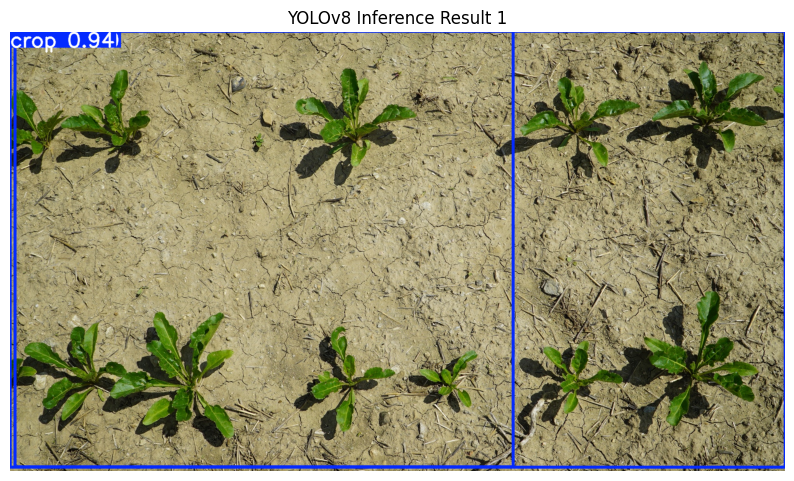

 Inference complete. Results saved to: /content/crop_model/custom_inference_run


In [ ]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import os

# Load the best trained model (if not already loaded)
model_path = '/content/crop_model/training_run/weights/best.pt'
if 'model' not in locals() or model.ckpt_path != model_path:
    model = YOLO(model_path)
    print(f" Model reloaded from: {model_path}")

# Prompt user for custom input path
custom_input_path = input("Enter the path to your custom image or directory (e.g., '/content/my_image.jpg' or '/content/drive/MyDrive/my_images_folder'): ")

if not os.path.exists(custom_input_path):
    print(f" Error: Path '{custom_input_path}' does not exist. Please check the path and try again.")
else:
    print(f" Running inference on: {custom_input_path}")

    # Perform inference
    # The 'conf' argument sets the object confidence threshold.
    # Only detections with a confidence score above this threshold will be shown.
    results = model.predict(source=custom_input_path, conf=0.25, save=True, project='crop_model', name='custom_inference_run')

    # Display results for images (if processing a single image or showing first few from directory)
    if os.path.isfile(custom_input_path) or (os.path.isdir(custom_input_path) and len(results) > 0):
        # For single image, or first few results if directory
        display_limit = 3 # Limit display to avoid too many plots for large directories
        for i, r in enumerate(results):
            if i >= display_limit:
                break
            im_array = r.plot()  # plot a BGR numpy array of predictions
            im = Image.fromarray(im_array[..., ::-1])  # RGB PIL image
            plt.figure(figsize=(10, 10))
            plt.imshow(im)
            plt.axis('off')
            plt.title(f'YOLOv8 Inference Result {i+1}')
            plt.show()
    elif os.path.isdir(custom_input_path) and len(results) == 0:
        print("No detections found in the provided directory.")

    print(f" Inference complete. Results saved to: /content/crop_model/custom_inference_run")


📊 Generating confusion matrix and other validation metrics...
Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1318.0±310.6 MB/s, size: 82.1 KB)
val: Scanning /content/dataset/labels/val.cache... 400 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 400/400 196.7Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 3.6it/s 7.0s
                   all        400        400      0.981      0.999      0.995      0.993
                  crop        128        128      0.985      0.999      0.995      0.994
                  weed        272        272      0.978          1      0.994      0.992
Speed: 2.2ms preprocess, 8.7ms inference, 0.0ms loss, 1.3ms postprocess per image
Saving /content/runs/detect/val2/predictions.json...
Results saved to /content/runs/detect/val2
✅ Normalized confusion matrix generated and saved to: /content/runs/

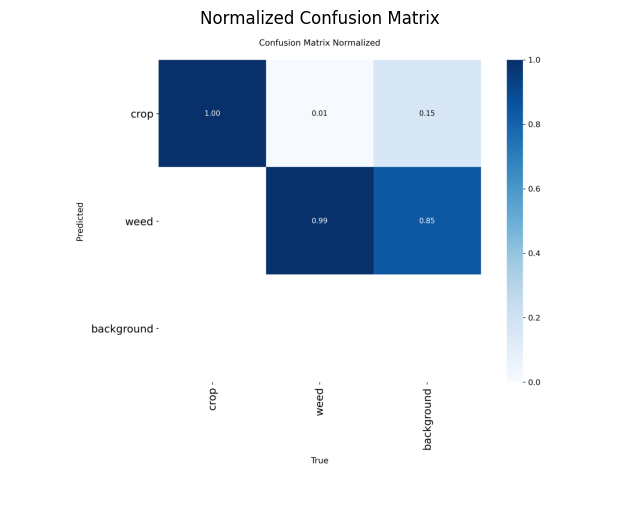

Validation complete.


In [ ]:
# ============================================================
# CELL 5: Generate Confusion Matrix and Validation Metrics
# ============================================================
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import os

# Load the best trained model (if not already loaded)
model_path = '/content/crop_model/training_run/weights/best.pt'
if 'model' not in locals() or model.ckpt_path != model_path:
    model = YOLO(model_path)
    print(f" Model reloaded from: {model_path}")

print(" Generating confusion matrix and other validation metrics...")

# Run validation on the model to generate the confusion matrix
# The results will be saved in the 'runs/detect/val/' directory
metrics = model.val(data='/content/data.yaml', save_json=True, plots=True, conf=0.25)

# Get the directory where the validation results are saved
results_dir = metrics.save_dir

# Construct the path to the NORMALIZED confusion matrix image
confusion_matrix_path_normalized = os.path.join(results_dir, 'confusion_matrix_normalized.png')

if os.path.exists(confusion_matrix_path_normalized):
    print(f" Normalized confusion matrix generated and saved to: {confusion_matrix_path_normalized}")
    # Display the normalized confusion matrix
    img = cv2.imread(confusion_matrix_path_normalized)
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Normalized Confusion Matrix')
    plt.show()
else:
    print(f" Could not find normalized confusion matrix at: {confusion_matrix_path_normalized}")

print("Validation complete.")


In [ ]:
import os

# The base directory where training results are saved, as reported by CELL 4
results_base_dir = '/content/crop_model/training_run'
weights_dir = os.path.join(results_base_dir, 'weights')

print(f"Checking existence of results base directory: {results_base_dir}")
if os.path.exists(results_base_dir):
    print(f"Results base directory {results_base_dir} exists. Listing its contents:")
    !ls -lh {results_base_dir}

    # Now, check for the weights directory specifically
    if os.path.exists(weights_dir):
        print(f"\nListing contents of the model weights directory: {weights_dir}")
        !ls -lh {weights_dir}
    else:
        print(f"\nThe weights directory {weights_dir} does not appear to exist within {results_base_dir}.")
else:
    print(f"The results base directory {results_base_dir} does not exist. This indicates the training output might not have been saved or is in a different location.")


Checking existence of results base directory: /content/crop_model/training_run
The results base directory /content/crop_model/training_run does not exist. This indicates the training output might not have been saved or is in a different location.


🖼️ Testing on sample image: /content/dataset/images/val/weed_indian-goosegrass_w4_0_13561.jpg

image 1/1 /content/dataset/images/val/weed_indian-goosegrass_w4_0_13561.jpg: 640x640 1 weed, 16.4ms
Speed: 3.3ms preprocess, 16.4ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/crop_model/inference_run2


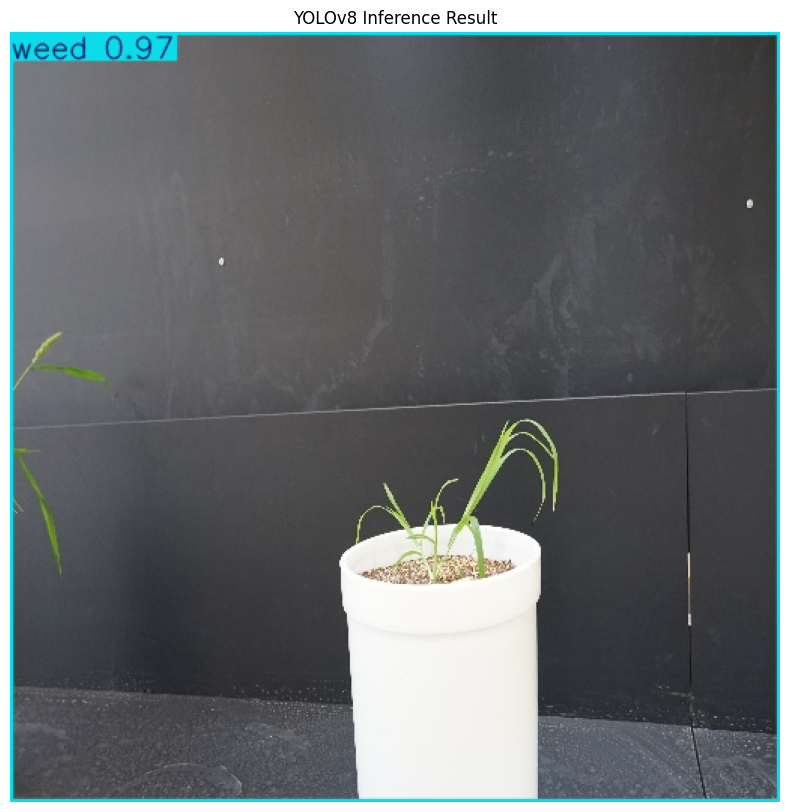

✅ Inference complete. Results saved to: /content/crop_model/inference_run


In [ ]:
# Get a random image from the validation set for testing
val_images_dir = '/content/dataset/images/val'
image_files = [os.path.join(val_images_dir, f) for f in os.listdir(val_images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]

if image_files:
    random_image_path = random.choice(image_files)
    print(f"Testing on sample image: {random_image_path}")

    # Perform inference
    # The 'conf' argument sets the object confidence threshold.
    # Only detections with a confidence score above this threshold will be shown.
    results = model.predict(source=random_image_path, conf=0.25, save=True, project='crop_model', name='inference_run')

    # Show results directly
    for r in results:
        im_array = r.plot()  # plot a BGR numpy array of predictions
        im = Image.fromarray(im_array[..., ::-1])  # RGB PIL image
        plt.figure(figsize=(10, 10))
        plt.imshow(im)
        plt.axis('off')
        plt.title('YOLOv8 Inference Result')
        plt.show()

    print(f"Inference complete. Results saved to: /content/crop_model/inference_run")
else:
    print(f"No images found in {val_images_dir} for testing.")